## Exercise 1.4 Hotdog -- no hotdog
This is the poster hand-in project for the course. Please see the associated PDF for instructions.

In [1]:
import os
import numpy as np
import glob
import PIL.Image as Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchvision.transforms import InterpolationMode


We always check that we are running on a GPU

In [2]:
if torch.cuda.is_available():
    print("The code will run on GPU.")
else:
    print("The code will run on CPU. Go to Edit->Notebook Settings and choose GPU as the hardware accelerator")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

The code will run on GPU.


We provide you with a class that can load the *hotdog/not hotdog* dataset you should use from /dtu/datasets1/02516/

In [3]:
class Hotdog_NotHotdog(torch.utils.data.Dataset):
    def __init__(self, train, transform, data_path='./hotdog_nothotdog'):
        'Initialization'
        self.transform = transform
        data_path = os.path.join(data_path, 'train' if train else 'test')
        image_classes = [os.path.split(d)[1] for d in glob.glob(data_path +'/*') if os.path.isdir(d)]
        image_classes.sort()
        self.name_to_label = {c: id for id, c in enumerate(image_classes)}
        self.image_paths = glob.glob(data_path + '/*/*.jpg')
        
    def __len__(self):
        'Returns the total number of samples'
        return len(self.image_paths)

    def __getitem__(self, idx):
        'Generates one sample of data'
        image_path = self.image_paths[idx]
        
        image = Image.open(image_path)
        c = os.path.split(os.path.split(image_path)[0])[1]
        y = self.name_to_label[c]
        X = self.transform(image)
        return X, y

Below is the simple way of converting the images to something that can be fed through a network.
Feel free to use something other than $128\times128$ images.

In [4]:
size = 128
train_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor(),
                                     transforms.Normalize((0.5,)*3, (0.5,)*3),])
test_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor(),
                                    transforms.Normalize((0.5,)*3, (0.5,)*3),])

batch_size = 64
trainset = Hotdog_NotHotdog(train=True, transform=train_transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=3)
testset = Hotdog_NotHotdog(train=False, transform=test_transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=3)

Let's look at some images from our data 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9372549].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..0.88235295].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid ran

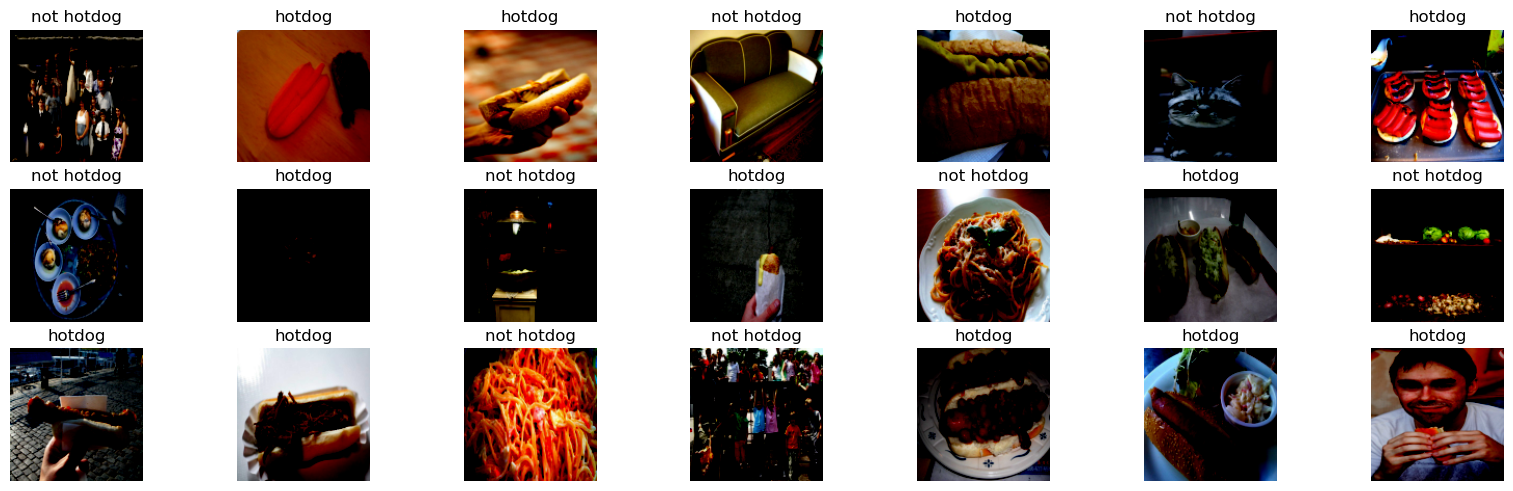

In [5]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(20,10))

for i in range(21):
    plt.subplot(5,7,i+1)
    plt.imshow(np.swapaxes(np.swapaxes(images[i].numpy(), 0, 2), 0, 1))
    plt.title(['hotdog', 'not hotdog'][labels[i].item()])
    plt.axis('off')


Now create a model and train it!


In [6]:
def train(model, optimizer, num_epochs=10, train_loader=train_loader):
    def loss_fun(output, target):
        # return F.nll_loss(output, target)
        return F.cross_entropy(output, target)
    out_dict = {'train_acc': [],
              'test_acc': [],
              'train_loss': [],
              'test_loss': []}
  
    for epoch in tqdm(range(num_epochs), unit='epoch'):
        model.train()
        #For each epoch
        train_correct = 0
        train_loss = []
        for minibatch_no, (data, target) in tqdm(enumerate(train_loader), total=len(train_loader)):
            data, target = data.to(device), target.to(device)
            #Zero the gradients computed for each weight
            optimizer.zero_grad()
            #Forward pass your image through the network
            output = model(data)
            #Compute the loss
            loss = loss_fun(output, target)
            #Backward pass through the network
            loss.backward()
            #Update the weights
            optimizer.step()

            train_loss.append(loss.item())
            #Compute how many were correctly classified
            predicted = output.argmax(1)
            train_correct += (target==predicted).sum().cpu().item()
        #Comput the test accuracy
        test_loss = []
        test_correct = 0
        model.eval()
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            with torch.no_grad():
                output = model(data)
            test_loss.append(loss_fun(output, target).cpu().item())
            predicted = output.argmax(1)
            test_correct += (target==predicted).sum().cpu().item()
        out_dict['train_acc'].append(train_correct/len(trainset))
        out_dict['test_acc'].append(test_correct/len(testset))
        out_dict['train_loss'].append(np.mean(train_loss))
        out_dict['test_loss'].append(np.mean(test_loss))
        print(f"Loss train: {np.mean(train_loss):.3f}\t test: {np.mean(test_loss):.3f}\t",
              f"Accuracy train: {out_dict['train_acc'][-1]*100:.1f}%\t test: {out_dict['test_acc'][-1]*100:.1f}%")
    return out_dict

In [7]:
def plot_training(out_dict):
    # X-axis = epoch numbers
    epochs = np.arange(1, len(out_dict['train_acc']) + 1)
    
    # --- Accuracy ---
    plt.figure(figsize=(6,4))
    plt.plot(epochs, np.array(out_dict['train_acc']) * 100, marker='o', label='Train accuracy')
    plt.plot(epochs, np.array(out_dict['test_acc']) * 100, marker='o', label='Test accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy vs. Epoch')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # --- Loss ---
    plt.figure(figsize=(6,4))
    plt.plot(epochs, out_dict['train_loss'], marker='o', label='Train loss')
    plt.plot(epochs, out_dict['test_loss'], marker='o', label='Test loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss vs. Epoch')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [8]:
# ---- SAVE CHECKPOINT ----
def save_checkpoint(path, model, optimizer, epoch,
                    scheduler=None, scaler=None, extra=None):
    ckpt = {
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "epoch": epoch,
    }
    if scheduler is not None:
        ckpt["scheduler"] = scheduler.state_dict()
    if scaler is not None:
        ckpt["scaler"] = scaler.state_dict()
    if extra is not None:
        ckpt["extra"] = extra  # e.g., best_acc, metrics history
    torch.save(ckpt, path)

# ---- LOAD & RESUME ----
def load_checkpoint(path, model, optimizer=None, scheduler=None, scaler=None, device="cpu"):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model"])
    if optimizer is not None and "optimizer" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer"])
    if scheduler is not None and "scheduler" in ckpt:
        scheduler.load_state_dict(ckpt["scheduler"])
    if scaler is not None and "scaler" in ckpt:
        scaler.load_state_dict(ckpt["scaler"])
    start_epoch = ckpt.get("epoch", -1) + 1
    extra = ckpt.get("extra", {})
    return start_epoch, extra


In [9]:
class TinyHotdogNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1, bias=False),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True)
            )
        self.features = nn.Sequential(
            block(3, 32), block(32, 32), nn.MaxPool2d(2),   # 128->64
            block(32, 64), block(64, 64), nn.MaxPool2d(2),  # 64->32
            block(64,128), block(128,128), nn.MaxPool2d(2), # 32->16
            # block(128,256), block(256,512), nn.Dropout(0.2),
            nn.Dropout2d(0.1)
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            # nn.Linear(16*16*256, 256),
            nn.Flatten(),
            # nn.Linear(16*16*128, 256),
            # nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.head(x)

In [10]:
model = TinyHotdogNet().to(device)
# criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)


  0%|          | 0/150 [00:00<?, ?epoch/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.627	 test: 0.607	 Accuracy train: 66.9%	 test: 68.0%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.552	 test: 0.603	 Accuracy train: 73.0%	 test: 66.7%


...

Loss train: 0.001	 test: 0.862	 Accuracy train: 100.0%	 test: 82.7%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.001	 test: 0.880	 Accuracy train: 100.0%	 test: 82.8%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.002	 test: 0.945	 Accuracy train: 100.0%	 test: 83.0%


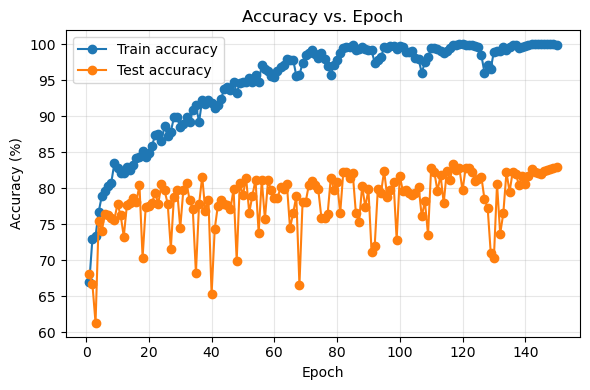

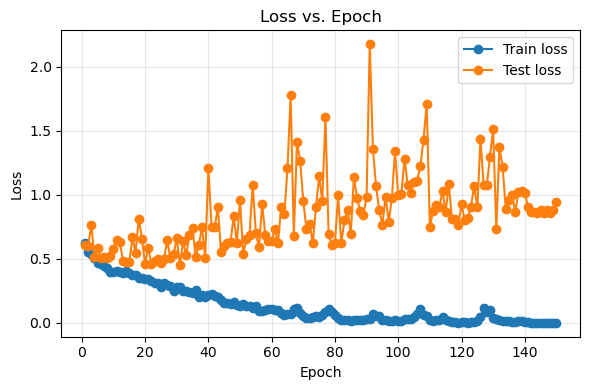

In [11]:
epochs = 150
out_dict = train(model, optimizer, epochs)
save_checkpoint("./saved_models/basic_model_long.pt", model, optimizer, epochs, extra=out_dict)
# start_epoch, extra = load_checkpoint("./saved_models/basic_model.pt", model, device=device)
# print(start_epoch)
plot_training(out_dict)

In [12]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0), ratio=(0.9, 1.1),
                                 interpolation=InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(p=0.25),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize((0.5,)*3, (0.5,)*3),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0),
])

batch_size = 64
trainset_aug = Hotdog_NotHotdog(train=True, transform=train_transform)
train_loader_aug = DataLoader(trainset_aug, batch_size=batch_size, shuffle=True, num_workers=3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.88235295..0.8745098].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8901961..0.90588236].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94509804..0.9137255].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9607843..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9843137].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.88235295].
Clipping in

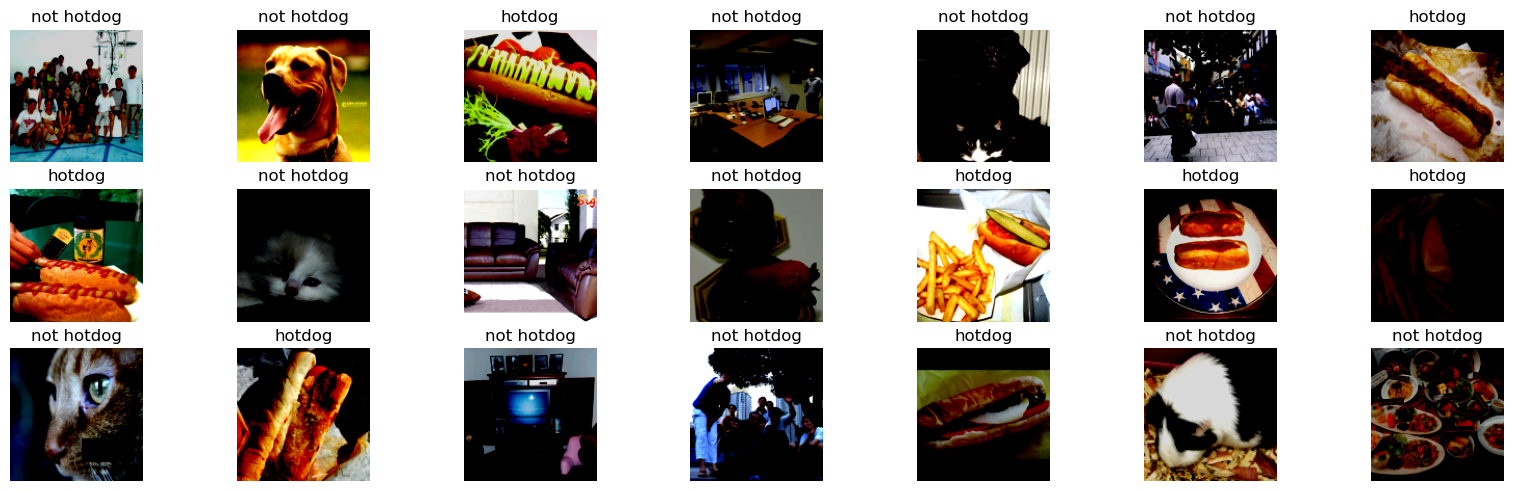

In [13]:
images, labels = next(iter(train_loader_aug))
plt.figure(figsize=(20,10))

for i in range(21):
    plt.subplot(5,7,i+1)
    plt.imshow(np.swapaxes(np.swapaxes(images[i].numpy(), 0, 2), 0, 1))
    plt.title(['hotdog', 'not hotdog'][labels[i].item()])
    plt.axis('off')

  0%|          | 0/150 [00:00<?, ?epoch/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.622	 test: 0.827	 Accuracy train: 67.1%	 test: 51.1%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.551	 test: 0.582	 Accuracy train: 72.5%	 test: 69.5%


...

Loss train: 0.062	 test: 0.724	 Accuracy train: 98.0%	 test: 82.3%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.069	 test: 0.932	 Accuracy train: 97.4%	 test: 80.0%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.061	 test: 0.802	 Accuracy train: 97.6%	 test: 82.8%


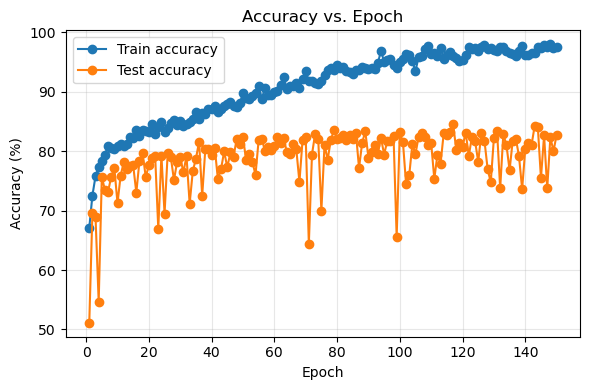

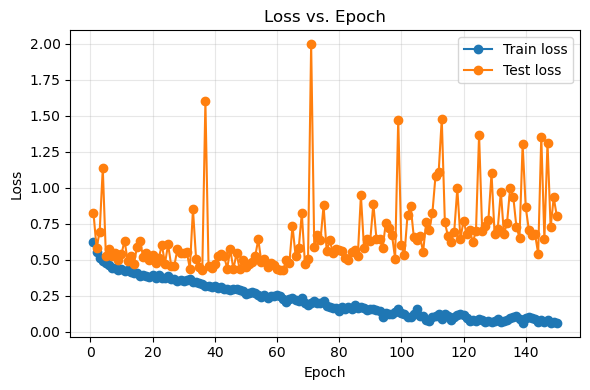

In [14]:
model_aug = TinyHotdogNet().to(device)
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 150
out_dict_aug = train(model_aug, optimizer_aug, epochs, train_loader=train_loader_aug)
save_checkpoint("./saved_models/augumentation_model_long.pt", model_aug, optimizer_aug, epochs, extra=out_dict_aug)
plot_training(out_dict_aug)

In [15]:
def plot_compare_trainings(dict1, dict2, title, labels, test=True):
    epochs = np.arange(1, len(out_dict['train_acc']) + 1)
    
    # --- Accuracy ---
    plt.figure(figsize=(6,4))
    if test:
        plt.plot(epochs, np.array(dict1['test_acc']) * 100, marker='o', label=labels[0])
        plt.plot(epochs, np.array(dict2['test_acc']) * 100, marker='o', label=labels[1])
    else:
        plt.plot(epochs, np.array(dict1['train_acc']) * 100, marker='o', label=labels[0])
        plt.plot(epochs, np.array(dict2['train_acc']) * 100, marker='o', label=labels[1])
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy vs. Epoch ' + str(title))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # --- Loss ---
    plt.figure(figsize=(6,4))
    if test:
        plt.plot(epochs, dict1['test_loss'], marker='o', label=labels[0])
        plt.plot(epochs, dict2['test_loss'], marker='o', label=labels[1])
    else:
        plt.plot(epochs, dict1['train_loss'], marker='o', label=labels[0])
        plt.plot(epochs, dict2['train_loss'], marker='o', label=labels[1])
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss vs. Epoch ' + str(title))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

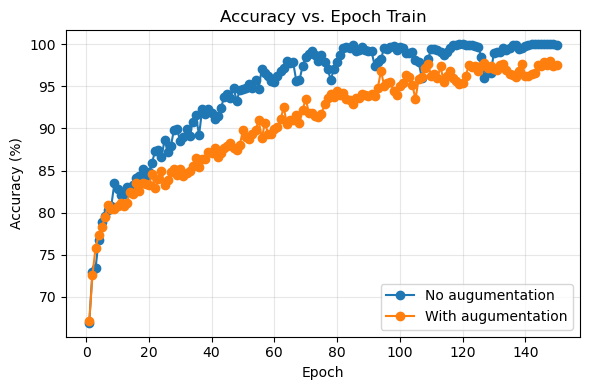

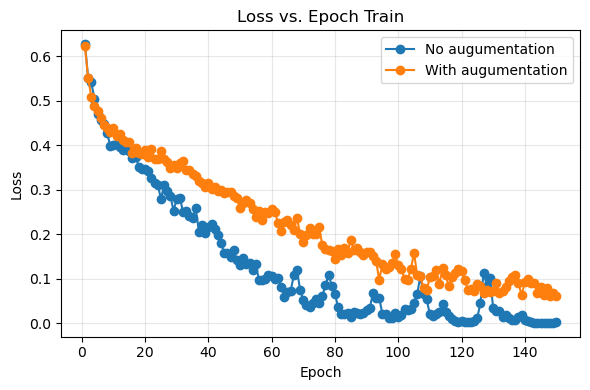

In [16]:
# epochs = np.arange(1, len(out_dict['train_acc']) + 1)

# # --- Accuracy ---
# plt.figure(figsize=(6,4))
# plt.plot(epochs, np.array(out_dict['train_acc']) * 100, marker='o', label='No augumentation')
# plt.plot(epochs, np.array(out_dict_aug['train_acc']) * 100, marker='o', label='With augumentation')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy (%)')
# plt.title('Accuracy vs. Epoch Train')
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()

# # --- Loss ---
# plt.figure(figsize=(6,4))
# plt.plot(epochs, out_dict['train_loss'], marker='o', label='No augumentation')
# plt.plot(epochs, out_dict_aug['train_loss'], marker='o', label='With augumentation')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.title('Loss vs. Epoch Train')
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()
plot_compare_trainings(out_dict, out_dict_aug, "Train", ['No augumentation', 'With augumentation'], test=False)

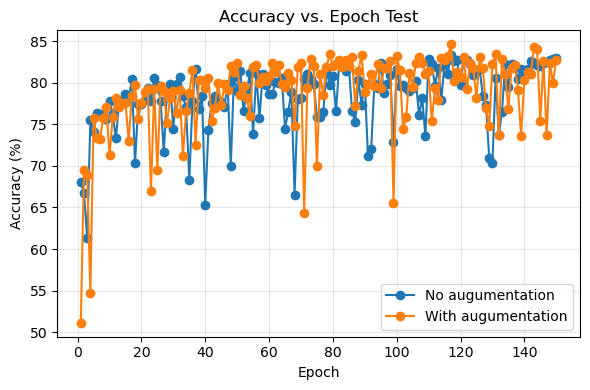

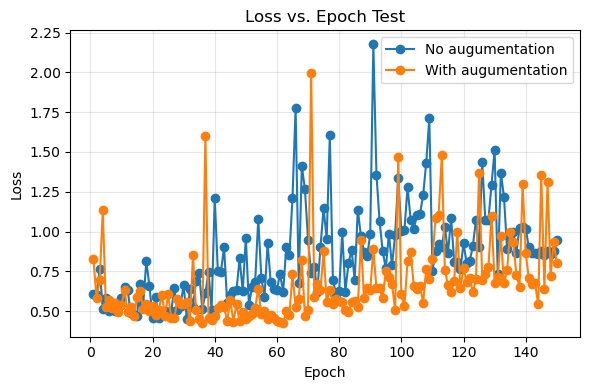

In [17]:
# epochs = np.arange(1, len(out_dict['test_acc']) + 1)

# # --- Accuracy ---
# plt.figure(figsize=(6,4))
# plt.plot(epochs, np.array(out_dict['test_acc']) * 100, marker='o', label='No augumentation')
# plt.plot(epochs, np.array(out_dict_aug['test_acc']) * 100, marker='o', label='With augumentation')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy (%)')
# plt.title('Accuracy vs. Epoch Test')
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()

# # --- Loss ---
# plt.figure(figsize=(6,4))
# plt.plot(epochs, out_dict['test_loss'], marker='o', label='No augumentation')
# plt.plot(epochs, out_dict_aug['test_loss'], marker='o', label='With augumentation')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.title('Loss vs. Epoch Test')
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()
plot_compare_trainings(out_dict, out_dict_aug, "Test", ['No augumentation', 'With augumentation'], test=True)

  0%|          | 0/150 [00:00<?, ?epoch/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.653	 test: 0.755	 Accuracy train: 62.1%	 test: 48.8%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.596	 test: 0.589	 Accuracy train: 69.6%	 test: 70.0%


...

Loss train: 0.192	 test: 0.445	 Accuracy train: 92.0%	 test: 82.2%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.203	 test: 0.627	 Accuracy train: 92.0%	 test: 81.0%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.181	 test: 0.772	 Accuracy train: 92.6%	 test: 77.7%


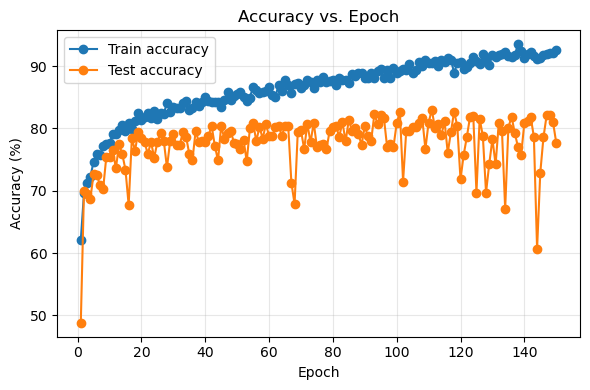

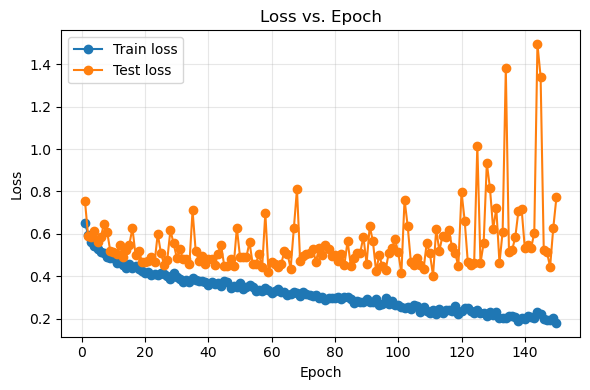

In [18]:
model_sgd = TinyHotdogNet().to(device)
# optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.001)
optimizer_sgd = torch.optim.SGD(
    model_sgd.parameters(),
    lr=0.001, 
    momentum=0.9,
    weight_decay=5e-4,
)
out_dict_sgd = train(model_sgd, optimizer_sgd, 150, train_loader=train_loader_aug)
plot_training(out_dict_sgd)

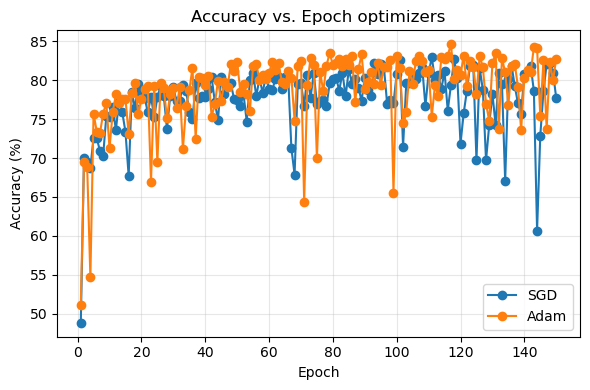

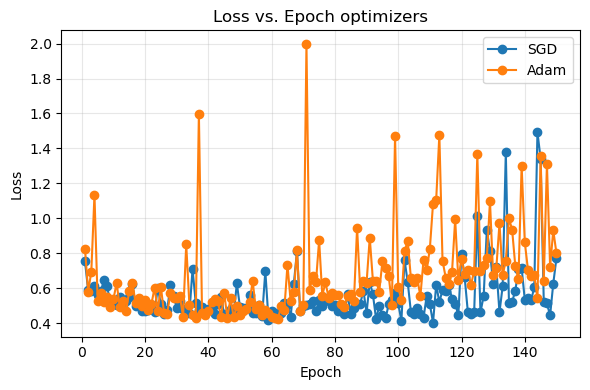

In [19]:
plot_compare_trainings(out_dict_sgd, out_dict_aug, title="optimizers", labels=["SGD", "Adam"])

In [20]:
class HotdogNoNorm(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1, bias=True),
                # nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True)
            )
        self.features = nn.Sequential(
            block(3, 32), block(32, 32), nn.MaxPool2d(2),   # 128->64
            block(32, 64), block(64, 64), nn.MaxPool2d(2),  # 64->32
            block(64,128), block(128,128), nn.MaxPool2d(2), # 32->16
            # block(128,256), block(256,512), nn.Dropout(0.2),
            nn.Dropout2d(0.1)
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            # nn.Linear(16*16*256, 256),
            nn.Flatten(),
            # nn.Linear(16*16*128, 256),
            # nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.head(x)

  0%|          | 0/150 [00:00<?, ?epoch/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.689	 test: 0.724	 Accuracy train: 54.3%	 test: 64.3%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.654	 test: 0.645	 Accuracy train: 65.0%	 test: 65.7%


...

Loss train: 0.146	 test: 0.682	 Accuracy train: 94.7%	 test: 79.9%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.124	 test: 0.670	 Accuracy train: 95.3%	 test: 80.7%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.161	 test: 0.621	 Accuracy train: 93.5%	 test: 81.4%


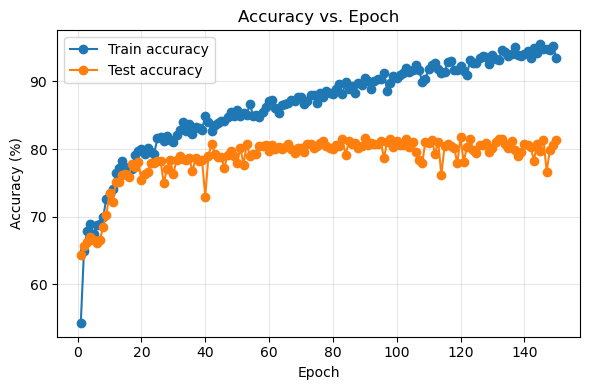

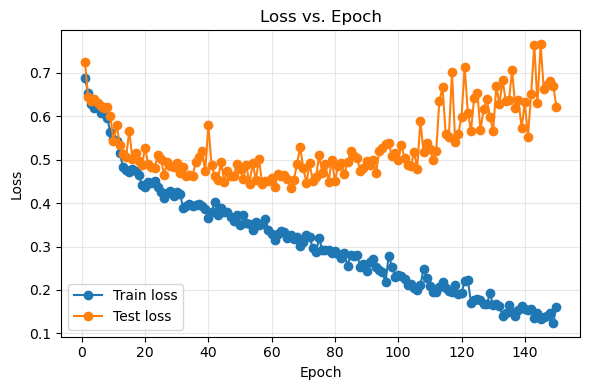

In [21]:
model_no_norm = HotdogNoNorm().to(device)
# optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.001)
optimizer_no_norm = torch.optim.Adam(model_no_norm.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 150
out_dict_no_norm = train(model_no_norm, optimizer_no_norm, epochs, train_loader=train_loader_aug)
save_checkpoint("./saved_models/no_norm_model.pt", model_no_norm, optimizer_no_norm, epochs, extra=out_dict_no_norm)
plot_training(out_dict_no_norm)

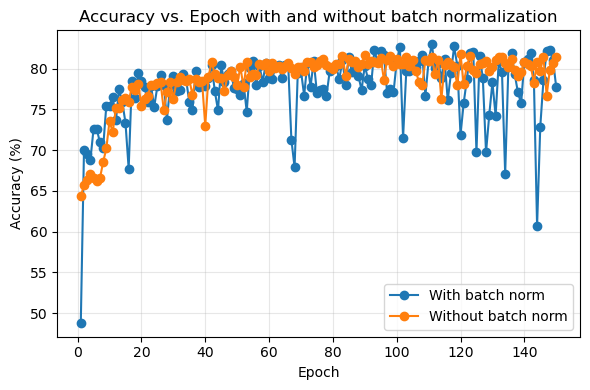

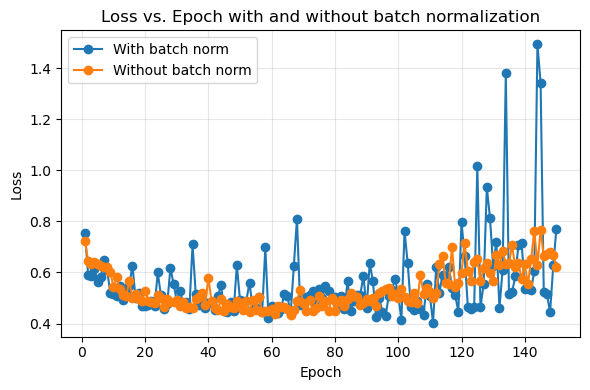

In [22]:
plot_compare_trainings(out_dict_sgd, out_dict_no_norm, title="with and without batch normalization", labels=["With batch norm", "Without batch norm"])

In [25]:
print(10*'-'+"normal model"+10*'-')
print("train acc ", min(out_dict['train_acc']), max(out_dict['train_acc']))
print("test acc ", min(out_dict['test_acc']), max(out_dict['test_acc']))
print("train loss ", min(out_dict['train_loss']), max(out_dict['train_loss']))
print("test loss ", min(out_dict['test_loss']), max(out_dict['test_loss']))

print(10*'-'+"with augumentation"+10*'-')
print("train acc ", min(out_dict_aug['train_acc']), max(out_dict_aug['train_acc']))
print("test acc ", min(out_dict_aug['test_acc']), max(out_dict_aug['test_acc']))
print("train loss ", min(out_dict_aug['train_loss']), max(out_dict_aug['train_loss']))
print("test loss ", min(out_dict_aug['test_loss']), max(out_dict_aug['test_loss']))

print(10*'-'+"without normalization"+10*'-')
print("train acc ", min(out_dict_no_norm['train_acc']), max(out_dict_no_norm['train_acc']))
print("test acc ", min(out_dict_no_norm['test_acc']), max(out_dict_no_norm['test_acc']))
print("train loss ", min(out_dict_no_norm['train_loss']), max(out_dict_no_norm['train_loss']))
print("test loss ", min(out_dict_no_norm['test_loss']), max(out_dict_no_norm['test_loss']))

print(10*'-'+"with SGD optimizer"+10*'-')
print("train acc ", min(out_dict_sgd['train_acc']), max(out_dict_sgd['train_acc']))
print("test acc ", min(out_dict_sgd['test_acc']), max(out_dict_sgd['test_acc']))
print("train loss ", min(out_dict_sgd['train_loss']), max(out_dict_sgd['train_loss']))
print("test loss ", min(out_dict_sgd['test_loss']), max(out_dict_sgd['test_loss']))


----------normal model----------
train acc  0.6692721055202736 1.0
test acc  0.6133190118152524 0.8340494092373791
train loss  0.0009578365952620516 0.6272059436887503
test loss  0.45249523023764293 2.1766095578360063
----------with augumentation----------
train acc  0.6712261846604788 0.979970688812897
test acc  0.5112781954887218 0.8464017185821697
train loss  0.0612201108597219 0.6224253475666046
test loss  0.4272032131751378 1.9959694757436712
----------without normalization----------
train acc  0.5432340009770396 0.9550561797752809
test acc  0.6433941997851772 0.8174006444683136
train loss  0.12441083160229027 0.6886538602411747
test loss  0.4343392829100291 0.7657512038946152
----------with SGD optimizer----------
train acc  0.6209086468001954 0.9350268685881779
test acc  0.4881847475832438 0.8297529538131042
train loss  0.18096406408585608 0.6526366267353296
test loss  0.40286020934581757 1.4938738143692414


In [30]:
# import numpy as np
# import matplotlib.pyplot as plt

# # --- tiny smoothing helpers ---
# def _moving_average(y, window=5):
#     if window is None or window <= 1: return np.asarray(y, float)
#     y = np.asarray(y, float)
#     return np.convolve(y, np.ones(window)/window, mode='same')

# def _ema(y, alpha=0.3):
#     if alpha is None or alpha <= 0 or alpha >= 1: return np.asarray(y, float)
#     y = np.asarray(y, float)
#     s = np.empty_like(y, float); s[0] = y[0]
#     for i in range(1, len(y)): s[i] = alpha*y[i] + (1-alpha)*s[i-1]
#     return s

# def _smooth(y, method=None, window=5, alpha=0.3):
#     if method == 'ma':  return _moving_average(y, window)
#     if method == 'ema': return _ema(y, alpha)
#     return np.asarray(y, float)

# def plot_compare_trainings(
#     dict1, dict2, title="", labels=("Run A", "Run B"), *,
#     test=True,
#     smooth='ema',      # 'ema', 'ma', or None
#     ema_alpha=0.3,
#     ma_window=5
# ):
#     key_acc  = 'test_acc'  if test else 'train_acc'
#     key_loss = 'test_loss' if test else 'train_loss'

#     # allow different run lengths
#     e1 = np.arange(1, len(dict1[key_acc]) + 1)
#     e2 = np.arange(1, len(dict2[key_acc]) + 1)

#     # accuracy (0..1)
#     y1a = _smooth(dict1[key_acc], method=smooth, window=ma_window, alpha=ema_alpha)
#     y2a = _smooth(dict2[key_acc], method=smooth, window=ma_window, alpha=ema_alpha)

#     # loss
#     y1l = _smooth(dict1[key_loss], method=smooth, window=ma_window, alpha=ema_alpha)
#     y2l = _smooth(dict2[key_loss], method=smooth, window=ma_window, alpha=ema_alpha)

#     # ---- Accuracy ----
#     plt.figure(figsize=(7, 4.2))
#     plt.plot(e1, y1a, linewidth=2.0, label=labels[0])
#     plt.plot(e2, y2a, linewidth=2.0, label=labels[1])
#     plt.title(f"Accuracy vs. Epoch — {title}")
#     plt.xlabel("Epoch"); plt.ylabel("Accuracy")   # no percent
#     plt.ylim(0, 1)                                # clamp to [0,1]
#     plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

#     # ---- Loss ----
#     plt.figure(figsize=(7, 4.2))
#     plt.plot(e1, y1l, linewidth=2.0, label=labels[0])
#     plt.plot(e2, y2l, linewidth=2.0, label=labels[1])
#     plt.title(f"Loss vs. Epoch — {title}")
#     plt.xlabel("Epoch"); plt.ylabel("Loss")
#     plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
#     if save_dir:
#         p = os.path.join(save_dir, f"{fname_prefix}_loss.{fmt}")
#         fig.savefig(p, bbox_inches='tight'); paths['loss'] = p
#     plt.show()
#     plt.close(fig)


In [41]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ---------- smoothing helpers ----------
def _moving_average(y, window=5):
    y = np.asarray(y, float)
    if window is None or window <= 1 or len(y) == 0:
        return y
    return np.convolve(y, np.ones(window)/window, mode='same')

def _ema(y, alpha=0.3):
    y = np.asarray(y, float)
    if alpha is None or not (0 < alpha < 1) or len(y) == 0:
        return y
    s = np.empty_like(y, float)
    s[0] = y[0]
    for i in range(1, len(y)):
        s[i] = alpha*y[i] + (1 - alpha)*s[i-1]
    return s

def _smooth(y, method=None, window=5, alpha=0.3):
    if method == 'ma':  return _moving_average(y, window)
    if method == 'ema': return _ema(y, alpha)
    return np.asarray(y, float)

# ---------- file helpers ----------
def _ensure_dir(d):
    if d:
        Path(d).mkdir(parents=True, exist_ok=True)

def _unique_path(save_dir, stem, fmt):
    """Return a unique path like stem.ext, stem-1.ext, stem-2.ext if exists."""
    base = Path(save_dir) / f"{stem}.{fmt}"
    if not base.exists():
        return str(base)
    k = 1
    while True:
        cand = Path(save_dir) / f"{stem}-{k}.{fmt}"
        if not cand.exists():
            return str(cand)
        k += 1

# ---------- single-run plot ----------
def plot_training(
    out_dict, *,
    smooth='ema', ema_alpha=0.3, ma_window=5,
    save_dir=None, fname_prefix='training', fmt='png', dpi=150, show=True
):
    """
    Plots accuracy (0..1) and loss vs epoch.
    If save_dir is provided, saves two files:
        <save_dir>/<fname_prefix>_acc.<fmt>
        <save_dir>/<fname_prefix>_loss.<fmt>
    Uses unique names if files already exist. Returns dict of file paths.
    """
    paths = {}
    _ensure_dir(save_dir) if save_dir else None

    e = np.arange(1, len(out_dict.get('train_acc', [])) + 1)

    tr_acc = _smooth(out_dict['train_acc'], method=smooth, window=ma_window, alpha=ema_alpha)
    te_acc = _smooth(out_dict['test_acc'],  method=smooth, window=ma_window, alpha=ema_alpha)
    tr_loss = _smooth(out_dict['train_loss'], method=smooth, window=ma_window, alpha=ema_alpha)
    te_loss = _smooth(out_dict['test_loss'],  method=smooth, window=ma_window, alpha=ema_alpha)

    # Accuracy
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.plot(e, tr_acc, linewidth=2.0, label='Train accuracy')
    ax.plot(e, te_acc, linewidth=2.0, label='Test accuracy')
    ax.set(xlabel='Epoch', ylabel='Accuracy', title='Accuracy vs. Epoch')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3); ax.legend(); fig.tight_layout()
    if save_dir:
        p = _unique_path(save_dir, f"{fname_prefix}_acc", fmt)
        fig.savefig(p, dpi=dpi, bbox_inches='tight'); paths['acc'] = p
    if show: plt.show()
    plt.close(fig)

    # Loss
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.plot(e, tr_loss, linewidth=2.0, label='Train loss')
    ax.plot(e, te_loss, linewidth=2.0, label='Test loss')
    ax.set(xlabel='Epoch', ylabel='Loss', title='Loss vs. Epoch')
    ax.grid(True, alpha=0.3); ax.legend(); fig.tight_layout()
    if save_dir:
        p = _unique_path(save_dir, f"{fname_prefix}_loss", fmt)
        fig.savefig(p, dpi=dpi, bbox_inches='tight'); paths['loss'] = p
    if show: plt.show()
    plt.close(fig)

    return paths

# ---------- compare two runs ----------
def plot_compare_trainings(
    dict1, dict2, title="", labels=("Run A", "Run B"), *,
    test=True,
    smooth='ema', ema_alpha=0.3, ma_window=5,
    save_dir=None, fname_prefix='compare', fmt='png', dpi=150, show=True
):
    """
    Compares two runs on accuracy (0..1) and loss.
    If save_dir is provided, saves:
        <save_dir>/<fname_prefix>_acc.<fmt>
        <save_dir>/<fname_prefix>_loss.<fmt>
    Uses unique names across repeated calls. Returns dict of file paths.
    """
    paths = {}
    _ensure_dir(save_dir) if save_dir else None

    key_acc  = 'test_acc'  if test else 'train_acc'
    key_loss = 'test_loss' if test else 'train_loss'

    e1 = np.arange(1, len(dict1[key_acc]) + 1)
    e2 = np.arange(1, len(dict2[key_acc]) + 1)

    y1a = _smooth(dict1[key_acc],  method=smooth, window=ma_window, alpha=ema_alpha)
    y2a = _smooth(dict2[key_acc],  method=smooth, window=ma_window, alpha=ema_alpha)
    y1l = _smooth(dict1[key_loss], method=smooth, window=ma_window, alpha=ema_alpha)
    y2l = _smooth(dict2[key_loss], method=smooth, window=ma_window, alpha=ema_alpha)

    # Accuracy
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.plot(e1, y1a, linewidth=2.0, label=labels[0])
    ax.plot(e2, y2a, linewidth=2.0, label=labels[1])
    ax.set(xlabel='Epoch', ylabel='Accuracy', title=f"Accuracy vs. Epoch — {title}")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3); ax.legend(); fig.tight_layout()
    if save_dir:
        p = _unique_path(save_dir, f"{fname_prefix}_acc", fmt)
        fig.savefig(p, dpi=dpi, bbox_inches='tight'); paths['acc'] = p
    if show: plt.show()
    plt.close(fig)

    # Loss
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.plot(e1, y1l, linewidth=2.0, label=labels[0])
    ax.plot(e2, y2l, linewidth=2.0, label=labels[1])
    ax.set(xlabel='Epoch', ylabel='Loss', title=f"Loss vs. Epoch — {title}")
    ax.grid(True, alpha=0.3); ax.legend(); fig.tight_layout()
    if save_dir:
        p = _unique_path(save_dir, f"{fname_prefix}_loss", fmt)
        fig.savefig(p, dpi=dpi, bbox_inches='tight'); paths['loss'] = p
    if show: plt.show()
    plt.close(fig)

    return paths


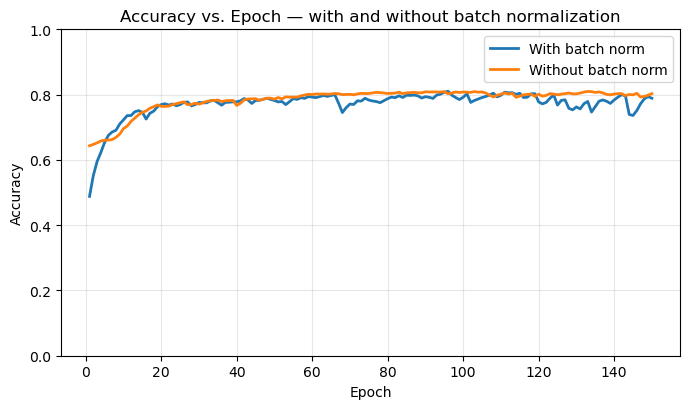

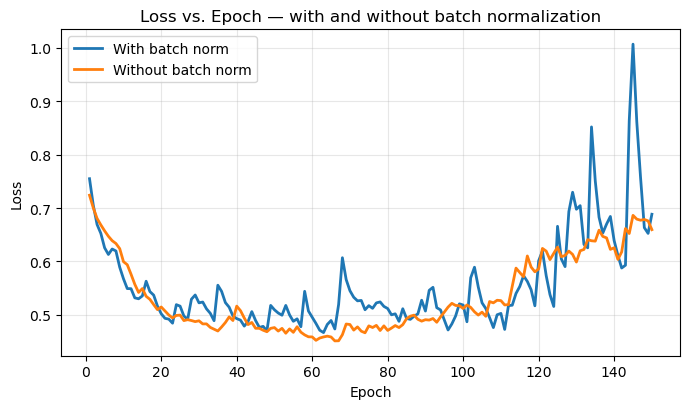

{'acc': 'plots/compare_acc-1.png', 'loss': 'plots/compare_loss-1.png'}

In [42]:
plot_compare_trainings(out_dict_sgd, out_dict_no_norm, title="with and without batch normalization", labels=["With batch norm", "Without batch norm"], save_dir="./plots")


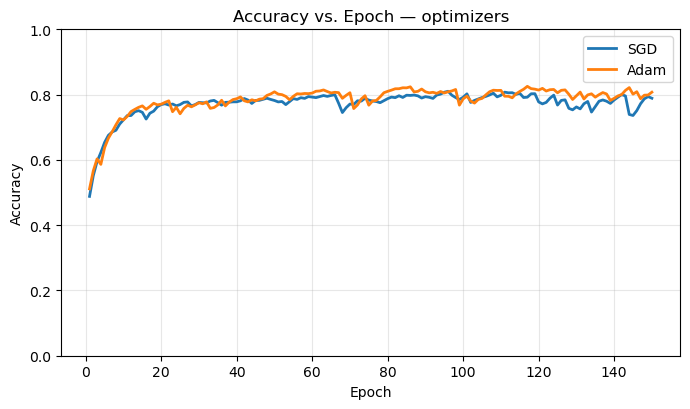

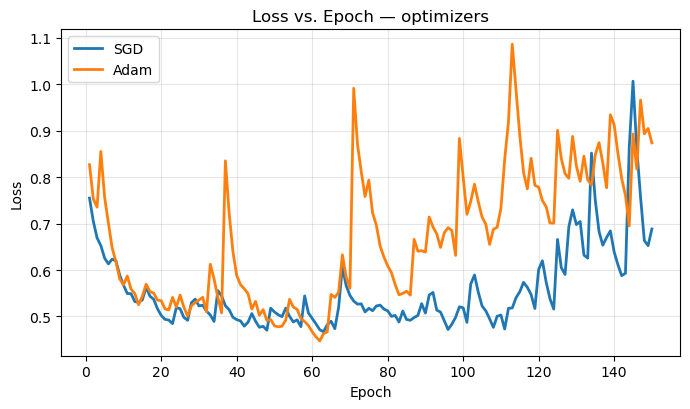

{'acc': 'plots/compare_acc-2.png', 'loss': 'plots/compare_loss-2.png'}

In [43]:
plot_compare_trainings(out_dict_sgd, out_dict_aug, title="optimizers", labels=["SGD", "Adam"], save_dir="./plots")


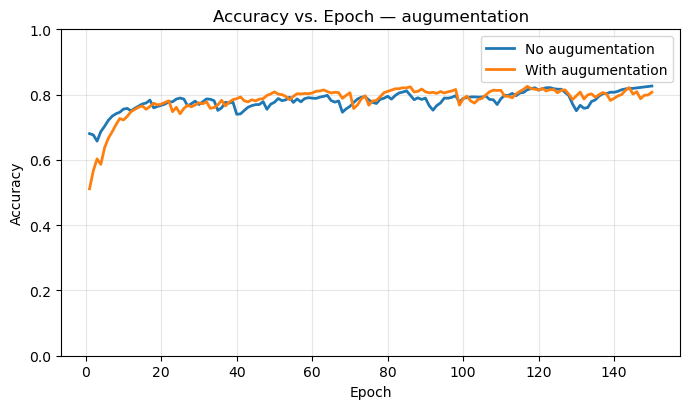

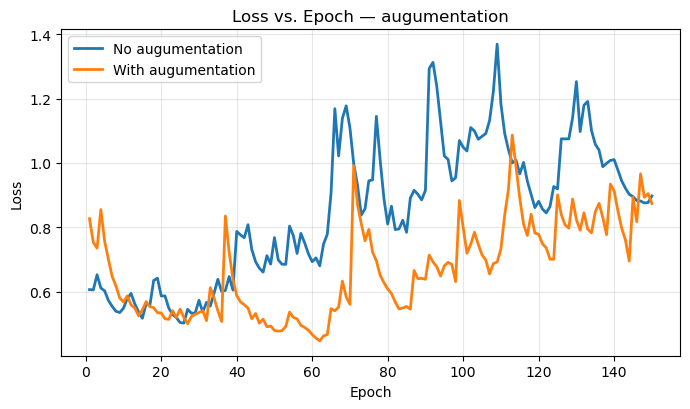

{'acc': 'plots/compare_acc-3.png', 'loss': 'plots/compare_loss-3.png'}

In [44]:
plot_compare_trainings(out_dict, out_dict_aug, "augumentation", ['No augumentation', 'With augumentation'], test=True, save_dir="./plots")